## Import Libraries

In [7]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import os
import numpy as np
from tifffile import imread
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
from skimage.segmentation import watershed, mark_boundaries
from skimage import measure
import pandas as pd


# Model Shape

In [18]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(f)
    return f, p


def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet(input_shape=(256,256, 3)):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(d4)

    model = keras.Model(inputs, outputs, name="MoNuSeg_U-Net")
    return model

## Show model summary statistics and parameters

In [19]:
# Free up RAM in case the model definition cells were run multiple times
keras.backend.clear_session()


# Build model
model = build_unet(input_shape=(256,256, 3))
model.summary()

Model: "MoNuSeg_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 64)      │           1,792 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 256, 256, 64)      │             256 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 256, 256, 64)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 64)      │          36,928 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 256, 256, 64)      │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 256, 256, 64)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 64)      │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 128)     │          73,856 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 128, 128, 128)     │             512 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 128, 128, 128)     │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 128)     │         147,584 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 128, 128, 128)     │             512 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 128, 128, 128)     │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 128)       │               0 │ activation_3[0][0]         │
│ (MaxPooling2D)                │                           │               

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

## Compute model optimization statistics (dice, loss, bce)

In [20]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model = build_unet(input_shape=(256, 256, 3))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=["accuracy", dice_coef]
)

### Enter image info, batch size, mask pairings

In [21]:
IMG_SIZE = 256
BATCH_SIZE = 4  ##splitting each epoch into 4 sample chunks
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

def get_image_mask_pairs(image_dir, mask_dir):
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])
    pairs = []

    for img_name in image_files:
        base = os.path.splitext(img_name)[0]
        mask_name = base + "_mask.tif"
        image_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            pairs.append((image_path, mask_path))
        else:
            print("Missing mask for:", img_name)

    return pairs

## Using Test/train split on patch images

In [22]:
train_image_dir = "./Dataset/Train/Patches/"
train_mask_dir  = "./Dataset/Train/Mask_Patches/"

val_image_dir = "./Dataset/Validation/Patches/"
val_mask_dir  = "./Dataset/Validation/Mask_Patches/"

test_image_dir = "./Dataset/Test/Tissue Images/"
test_mask_dir  = "./Dataset/Test/Binary_Masks/"


train_pairs = get_image_mask_pairs(train_image_dir, train_mask_dir)
val_pairs   = get_image_mask_pairs(val_image_dir, val_mask_dir)
test_pairs = get_image_mask_pairs(test_image_dir, test_mask_dir)

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))

Train pairs: 120
Val pairs: 28
Test pairs: 14


### Functions

In [23]:
def load_image_mask(image_path, mask_path):
    image = imread(image_path.decode())
    mask = imread(mask_path.decode())

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] > 3:
        image = image[..., :3]

    image = image.astype(np.float32)
    if image.max() > 1:
        image = image / 255.0

    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)).numpy()
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest").numpy()

    return image.astype(np.float32), mask.astype(np.float32)

def tf_load_image_mask(image_path, mask_path):
    image, mask = tf.numpy_function(
        load_image_mask,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return image, mask

def augment(image, mask):
    # Flip left/right
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Flip up/down
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Rotate 0, 90, 180, 270
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    return image, mask

def make_dataset(pairs, batch_size=4, training=False):
    image_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(tf_load_image_mask, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_pairs, batch_size=BATCH_SIZE, training=True)
val_ds = make_dataset(val_pairs, batch_size=BATCH_SIZE, training=False)

Image batch shape: (4, 256, 256, 3)
Mask batch shape: (4, 256, 256, 1)
Mask values min/max: 0.0 1.0


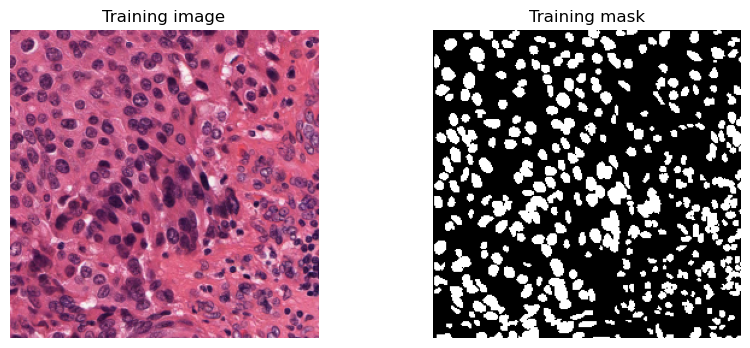

In [24]:
images, masks = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Mask values min/max:", tf.reduce_min(masks).numpy(), tf.reduce_max(masks).numpy())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[0].numpy())
plt.title("Training image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[0].numpy().squeeze(), cmap="gray")
plt.title("Training mask")
plt.axis("off")

plt.show()

## Callbacks to train actual model!

In [25]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,   ## Important! change number of epochs
    callbacks=callbacks
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 306s 10s/step - accuracy: 0.7340 - dice_coef: 0.4922 - loss: 1.0915 - val_accuracy: 0.6417 - val_dice_coef: 0.4062 - val_loss: 1.2624
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 292s 10s/step - accuracy: 0.8609 - dice_coef: 0.5857 - loss: 0.8404 - val_accuracy: 0.6417 - val_dice_coef: 0.4010 - val_loss: 1.2352
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 288s 10s/step - accuracy: 0.8775 - dice_coef: 0.6202 - loss: 0.7458 - val_accuracy: 0.6417 - val_dice_coef: 0.3650 - val_loss: 1.2623
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 287s 10s/step - accuracy: 0.8870 - dice_coef: 0.6480 - loss: 0.6808 - val_accuracy: 0.6417 - val_dice_coef: 0.3258 - val_loss: 1.3189
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 288s 10s/step - accuracy: 0.8901 - dice_coef: 0.6589 - loss: 0.6545 - val_accuracy: 0.6427 - val_dice_coef: 0.3237 - val_loss: 1.3218
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 292s 10s/step - accuracy: 0.8962 - dice_coef: 0.6744 - loss: 0.6155 - val_accuracy: 0.6730 - val_dice_

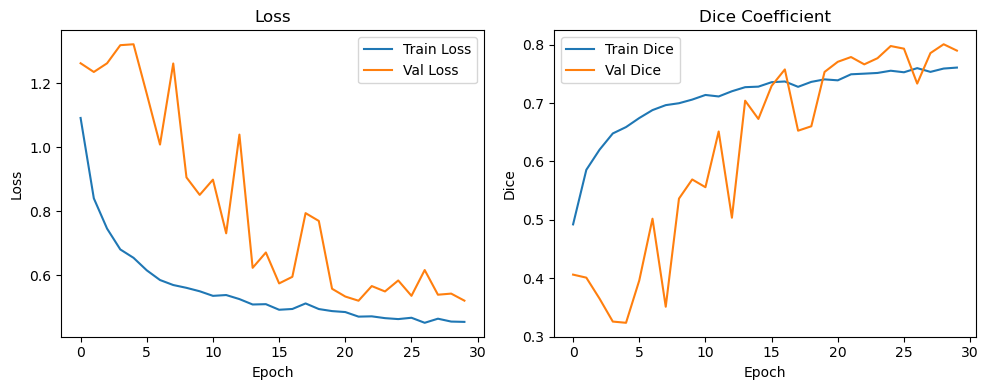

In [26]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["dice_coef"], label="Train Dice")
plt.plot(history.history["val_dice_coef"], label="Val Dice")
plt.title("Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


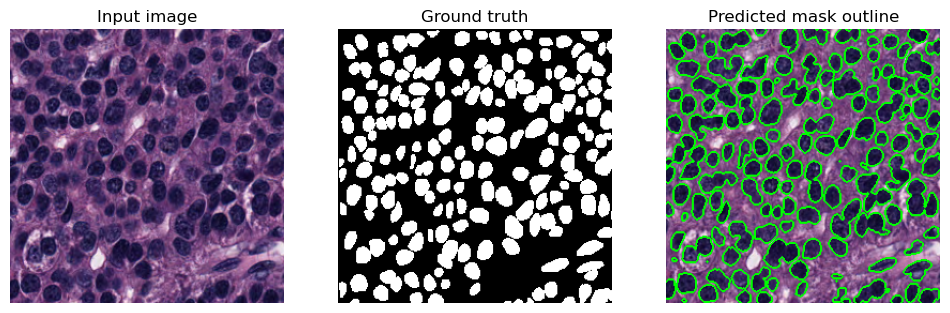

In [27]:
val_images, val_masks = next(iter(val_ds))
preds = model.predict(val_images)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(val_images[0].numpy())
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(val_masks[0].numpy().squeeze(), cmap="gray")
plt.title("Ground truth")
plt.axis("off")

# Subplot 3: Outline Overlay
plt.subplot(1, 3, 3)
# Convert thresholded boolean mask to int so mark_boundaries recognizes it as a label
pred_mask = (preds[0].squeeze() > 0.5).astype(np.uint8)

# Apply only the outline (no solid filling)
overlay = mark_boundaries(val_images[0].numpy(), pred_mask, color=(0, 1, 0), mode="thick")

plt.imshow(overlay)
plt.title("Predicted mask outline")
plt.axis("off")
plt.show()

In [28]:
all_val_images = []
all_val_masks = []
all_val_preds = []

for images, masks in val_ds:
    preds = model.predict(images, verbose=0)
    
    all_val_images.append(images.numpy())
    all_val_masks.append(masks.numpy())
    all_val_preds.append(preds)

all_val_images = np.concatenate(all_val_images, axis=0)
all_val_masks = np.concatenate(all_val_masks, axis=0)
all_val_preds = np.concatenate(all_val_preds, axis=0)

print("Validation images:", all_val_images.shape)
print("Validation masks:", all_val_masks.shape)
print("Validation predictions:", all_val_preds.shape)

Validation images: (28, 256, 256, 3)
Validation masks: (28, 256, 256, 1)
Validation predictions: (28, 256, 256, 1)


In [29]:
pred_binary = (all_val_preds > 0.5).astype(np.uint8)
gt_binary = (all_val_masks > 0.5).astype(np.uint8)

In [30]:
def compute_binary_metrics(gt_mask, pred_mask):
    gt = gt_mask.astype(bool)
    pred = pred_mask.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    tn = np.logical_and(~gt, ~pred).sum()

    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dice, iou, precision, recall, specificity

In [85]:
def compute_binary_metrics(gt_mask, pred_mask):
    gt = gt_mask.astype(bool)
    pred = pred_mask.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    tn = np.logical_and(~gt, ~pred).sum()

    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dice, iou, precision, recall, specificity

In [86]:
def compute_count_metrics(gt_mask, pred_mask):
    gt_labels = measure.label(gt_mask)
    pred_labels = measure.label(pred_mask)

    gt_count = gt_labels.max()
    pred_count = pred_labels.max()

    count_difference = pred_count - gt_count
    
    if gt_count > 0:
        count_error = abs(count_difference) / gt_count
        count_accuracy = 1 - count_error
    else:
        count_error = np.nan
        count_accuracy = np.nan

    return gt_count, pred_count, count_difference, count_error, count_accuracy

In [74]:
rows = []

for i in range(len(pred_binary)):
    gt = gt_binary[i].squeeze()
    pred = pred_binary[i].squeeze()

    dice, iou, precision, recall, specificity = compute_binary_metrics(gt, pred)
    gt_count, pred_count, count_difference, count_error, count_accuracy = compute_count_metrics(gt, pred)

    # Get filename from val_pairs
    image_path = val_pairs[i][0]
    image_name = os.path.basename(image_path)

    rows.append({
        "image_name": image_name,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "gt_nuclei_count": gt_count,
        "pred_nuclei_count": pred_count,
        "count_difference": count_difference,
        "count_error": count_error,
        "count_accuracy": count_accuracy
    })

df_val_results = pd.DataFrame(rows)

## Metrics by Tissue Type

In [34]:
# Load the TCGA tissue code table
tcga_codes = pd.read_csv("TCGA_codes.txt", sep="\t")

# Create dictionary: TSS Code -> Study Name
tissue_dict = dict(zip(tcga_codes["TSS Code"], tcga_codes["Study Name"]))


def get_tissue_type(filename):
    # Extract TSS code from filename
    # TCGA-B0-XXXX → B0
    tss_code = filename.split("-")[1]
    
    return tissue_dict.get(tss_code, "Unknown")

def group_tissue(cancer_name):
    if "Breast" in cancer_name:
        return "Breast"
    elif "Kidney" in cancer_name:
        return "Kidney"
    elif "Lung" in cancer_name:
        return "Lung"
    elif "Colon" in cancer_name or "Rectum" in cancer_name:
        return "Colon"
    elif "Liver" in cancer_name:
        return "Liver"
    elif "Head and Neck" in cancer_name:
        return "Head & Neck"
    elif "Prostate" in cancer_name:
        return "Prostate"
    elif "Bladder" in cancer_name:
        return "Bladder"
    elif "Skin" in cancer_name:
        return "Skin"
    elif "Pancreatic" in cancer_name:
        return "Pancreas"
    elif "Stomach" in cancer_name:
        return "Stomach"
    elif "Cervical" in cancer_name:
        return "Cervical"
    else:
        return "Other"


In [35]:
df_val_results["base_image"] = df_val_results["image_name"].str.replace(r"_patch_\d+", "", regex=True)

df_val_results["tissue_type"] = df_val_results["base_image"].apply(get_tissue_type)
df_val_results["tissue_group"] = df_val_results["tissue_type"].apply(group_tissue)

df_val_results.to_csv("validation_evaluation_results.csv", index=False)

In [36]:
print(df_val_results.shape)
print(df_val_results.columns)

(28, 13)
Index(['image_name', 'dice', 'iou', 'precision', 'recall', 'gt_nuclei_count',
       'pred_nuclei_count', 'count_difference', 'count_error',
       'count_accuracy', 'base_image', 'tissue_type', 'tissue_group'],
      dtype='object')


### Segmentation Overlap Metrics

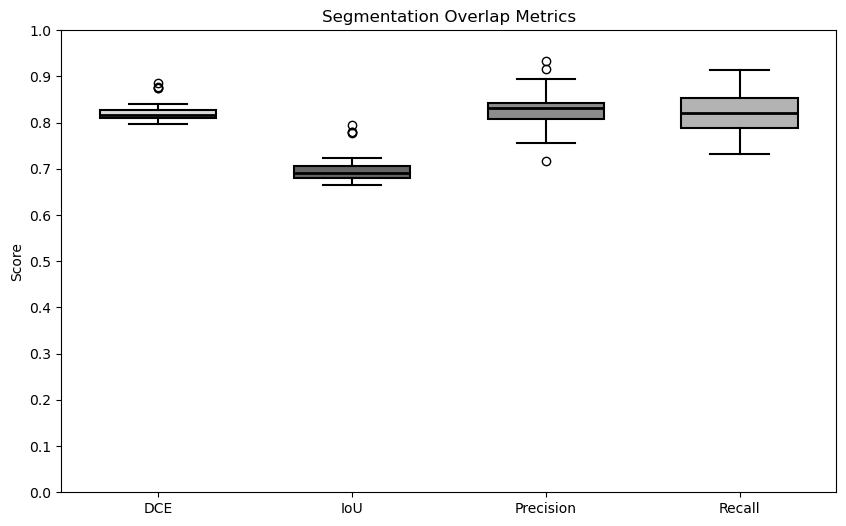

In [37]:
metrics = ["dice", "iou", "precision", "recall"]
labels_display = ["DCE", "IoU", "Precision", "Recall"]

data = [df_val_results[m].dropna() for m in metrics]

plt.figure(figsize=(10, 6))

box = plt.boxplot(
    data,
    patch_artist=True,   # allows box fill
    widths=0.6
)

# Shades of gray for each box
gray_colors = ["0.85", "0.4", "0.55", "0.7"]

# Style boxes
for patch, color in zip(box['boxes'], gray_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style whiskers, caps, medians
for whisker in box['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(1.5)

for cap in box['caps']:
    cap.set_color('black')
    cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Remove gridlines
plt.grid(False)

## Axis labels
# Use custom axis labels here
plt.xticks([1, 2, 3, 4], labels_display)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylabel("Score")
plt.title("Segmentation Overlap Metrics")
plt.savefig("Segmentation_Overlap_Metrics.jpg", dpi=300, bbox_inches="tight")

plt.show()



## Predicted vs ground truth nuclei count

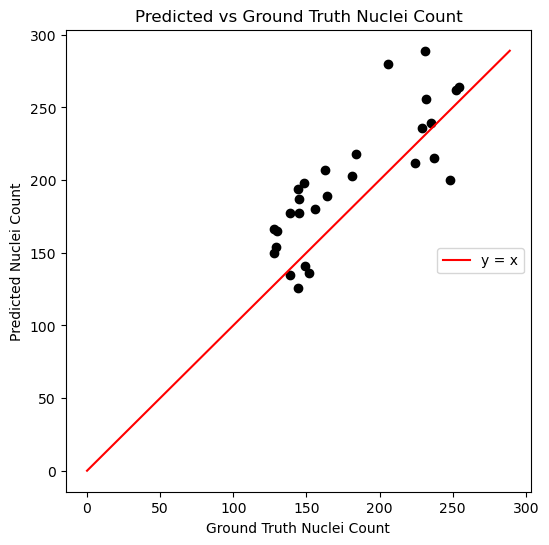

In [38]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df_val_results["gt_nuclei_count"],
    df_val_results["pred_nuclei_count"],
    color = 'black'
)

plt.xlabel("Ground Truth Nuclei Count")
plt.ylabel("Predicted Nuclei Count")
plt.title("Predicted vs Ground Truth Nuclei Count")

# Plot y = x line
max_val = max(df_val_results["gt_nuclei_count"].max(),
              df_val_results["pred_nuclei_count"].max())
plt.plot([0, max_val], [0, max_val], color = 'red', label='y = x')
plt.legend(loc= 'center right')


plt.savefig("Predicted vs ground truth nuclei count.jpg", dpi=300, bbox_inches="tight")

plt.show() 

## DCE by tissue type

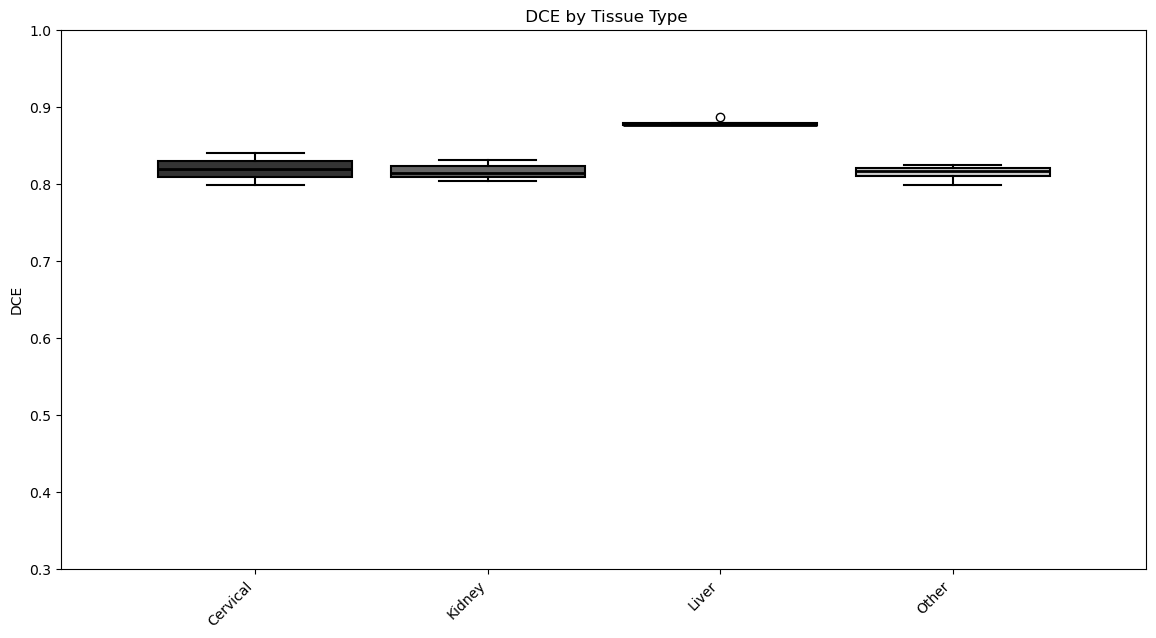

In [39]:
metrics = ["dice"]
labels_display = ["DCE"]
tissues = sorted(df_val_results["tissue_group"].dropna().unique())

fig, ax = plt.subplots(figsize=(14, 7))

positions = []
data = []
colors = ["0.2", "0.4", "0.6", "0.8", "0.3", "0.5", "0.7"]


pos = 0.5
for tissue in tissues:
    df_t = df_val_results[df_val_results["tissue_group"] == tissue]

    for m in metrics:
        data.append(df_t[m].dropna())
        positions.append(pos)
        pos += 0.1

    pos += 0.5   # space between tissue groups

box = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.5
)

# Style boxes
for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

# X-axis labels centered on each tissue box
tick_positions = positions
tick_labels = tissues

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.grid(False)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0.3, 1)
plt.ylabel("DCE")
plt.title(" DCE by Tissue Type")

plt.savefig("DCE_By_Tissue.jpg", dpi=300, bbox_inches="tight")
plt.show()

## Test set

In [100]:
test_image_dir = "./Dataset/Test/Patches/"
test_mask_dir  = "./Dataset/Test/Mask_Patches/"

test_pairs = get_image_mask_pairs(test_image_dir, test_mask_dir)
test_ds = make_dataset(test_pairs, batch_size=BATCH_SIZE, training=False)

test_results = model.evaluate(test_ds)
print(test_results)

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9030 - dice_coef: 0.7035 - loss: 0.5309
[0.5308572053909302, 0.9030459523200989, 0.7035245299339294]


In [101]:
# -----------------------------
# Collect all test images, masks, predictions
# -----------------------------
all_test_images = []
all_test_masks = []
all_test_preds = []

for images, masks in test_ds:
    preds = model.predict(images, verbose=0)

    all_test_images.append(images.numpy())
    all_test_masks.append(masks.numpy())
    all_test_preds.append(preds)

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_masks = np.concatenate(all_test_masks, axis=0)
all_test_preds = np.concatenate(all_test_preds, axis=0)

print("Test images:", all_test_images.shape)
print("Test masks:", all_test_masks.shape)
print("Test predictions:", all_test_preds.shape)

Test images: (56, 256, 256, 3)
Test masks: (56, 256, 256, 1)
Test predictions: (56, 256, 256, 1)


In [102]:
# -----------------------------
# Threshold test predictions
# -----------------------------
pred_test_binary = (all_test_preds > 0.5).astype(np.uint8)
gt_test_binary = (all_test_masks > 0.5).astype(np.uint8)

In [103]:
# -----------------------------
# Build test results dataframe
# -----------------------------
rows = []

for i in range(len(pred_test_binary)):
    gt = gt_test_binary[i].squeeze()
    pred = pred_test_binary[i].squeeze()

    dice, iou, precision, recall, specificity = compute_binary_metrics(gt, pred)
    gt_count, pred_count, count_difference, count_error, count_accuracy = compute_count_metrics(gt, pred)

    image_path = test_pairs[i][0]
    image_name = os.path.basename(image_path)

    rows.append({
        "image_name": image_name,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "gt_nuclei_count": gt_count,
        "pred_nuclei_count": pred_count,
        "count_difference": count_difference,
        "count_error": count_error,
        "count_accuracy": count_accuracy
    })

df_test_results = pd.DataFrame(rows)
print(df_test_results.shape)
print(df_test_results.columns)
df_test_results.head()

# -----------------------------
# Add tissue metadata
# -----------------------------
df_test_results["base_image"] = df_test_results["image_name"].str.replace(r"_patch_\d+", "", regex=True)

df_test_results["tissue_type"] = df_test_results["base_image"].apply(get_tissue_type)
df_test_results["tissue_group"] = df_test_results["tissue_type"].apply(group_tissue)

df_test_results.to_csv("test_evaluation_results.csv", index=False)

(56, 10)
Index(['image_name', 'dice', 'iou', 'precision', 'recall', 'gt_nuclei_count',
       'pred_nuclei_count', 'count_difference', 'count_error',
       'count_accuracy'],
      dtype='object')


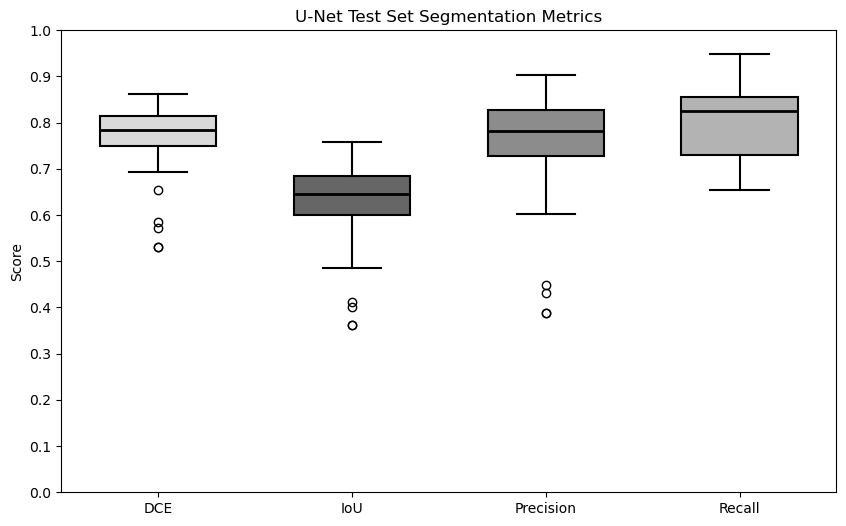

In [104]:
# -----------------------------
# Test overlap metrics boxplot
# -----------------------------
metrics = ["dice", "iou", "precision", "recall"]
labels_display = ["DCE", "IoU", "Precision", "Recall"]

data = [df_test_results[m].dropna() for m in metrics]

plt.figure(figsize=(10, 6))

box = plt.boxplot(
    data,
    patch_artist=True,
    widths=0.6
)

gray_colors = ["0.85", "0.4", "0.55", "0.7"]

for patch, color in zip(box["boxes"], gray_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

plt.grid(False)
plt.xticks([1, 2, 3, 4], labels_display)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("U-Net Test Set Segmentation Metrics")
plt.savefig("U-Net_Test_Segmentation_Metrics.jpg", dpi=300, bbox_inches="tight")
plt.show()

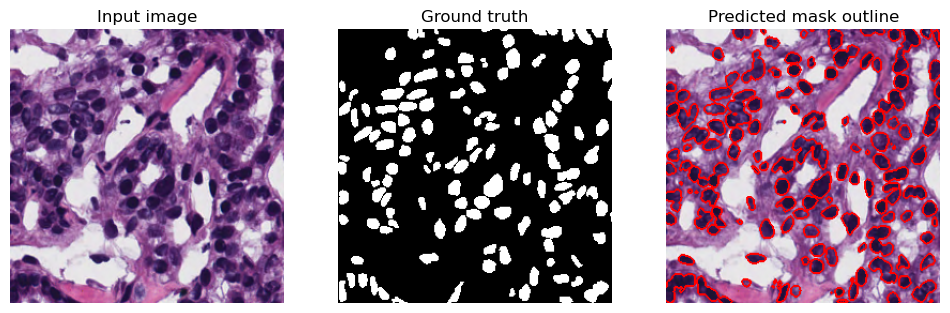

In [108]:
# -----------------------------
# Example test prediction overlay
# -----------------------------
idx = 2

gt_mask = all_test_masks[idx].squeeze()
pred_mask = pred_test_binary[idx].squeeze().astype(np.uint8)

overlay = mark_boundaries(
    all_test_images[idx],
    pred_mask,
    color=(1, 0, 0),
    mode="thick"
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(all_test_images[idx])
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Predicted mask outline")
plt.axis("off")


plt.show()

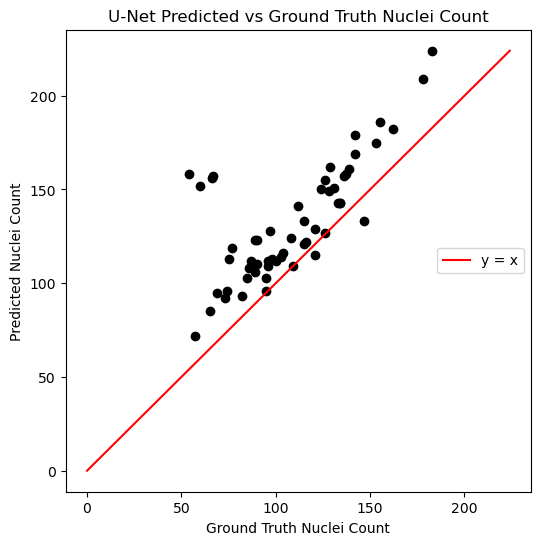

In [107]:
# -----------------------------
# Test count scatter plot
# -----------------------------
plt.figure(figsize=(6, 6))

plt.scatter(
    df_test_results["gt_nuclei_count"],
    df_test_results["pred_nuclei_count"],
    color="black"
)

plt.xlabel("Ground Truth Nuclei Count")
plt.ylabel("Predicted Nuclei Count")
plt.title("U-Net Predicted vs Ground Truth Nuclei Count")

max_test = max(
    df_test_results["gt_nuclei_count"].max(),
    df_test_results["pred_nuclei_count"].max()
)

plt.plot([0, max_test], [0, max_test], color="red", label="y = x")
plt.legend(loc="center right")

plt.savefig("U-Net_Predicted_vs_Ground_Truth_Nuclei_Count.jpg", dpi=300, bbox_inches="tight")
plt.show()

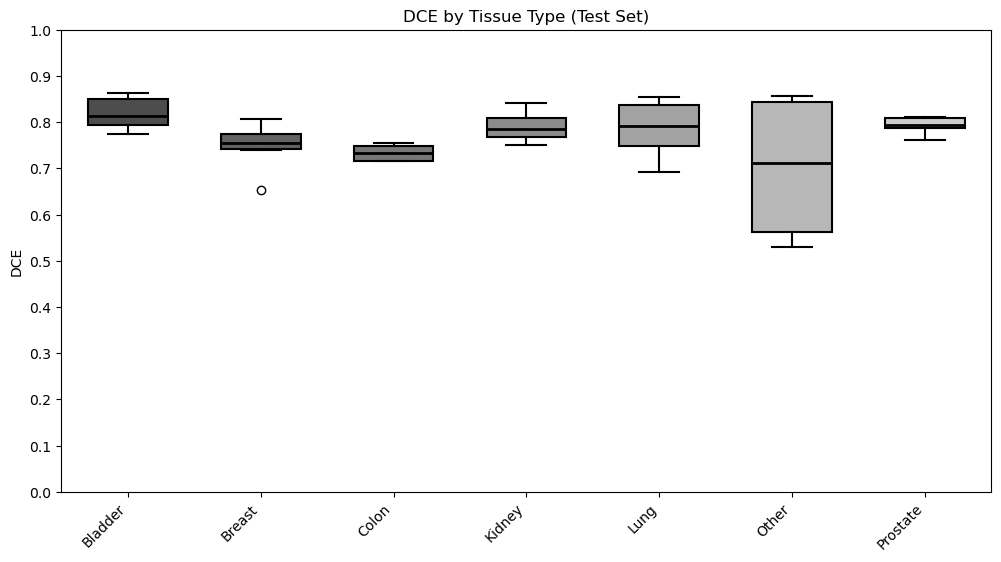

In [109]:
# Use test results (or validation if you prefer)
df = df_test_results

# Get sorted tissue groups
tissues = sorted(df["tissue_group"].dropna().unique())

# Collect data per tissue
data = [df[df["tissue_group"] == t]["dice"].dropna() for t in tissues]

plt.figure(figsize=(12, 6))

box = plt.boxplot(
    data,
    patch_artist=True,
    widths=0.6
)

# Shades of gray
gray_colors = np.linspace(0.3, 0.8, len(tissues))

for patch, color in zip(box["boxes"], gray_colors):
    patch.set_facecolor(str(color))
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

# Axis formatting
plt.xticks(range(1, len(tissues) + 1), tissues, rotation=45, ha="right")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)

plt.ylabel("DCE")
plt.title("DCE by Tissue Type (Test Set)")

plt.grid(False)

plt.savefig("DCE_By_Tissue_Type_Test.jpg", dpi=300, bbox_inches="tight")
plt.show()

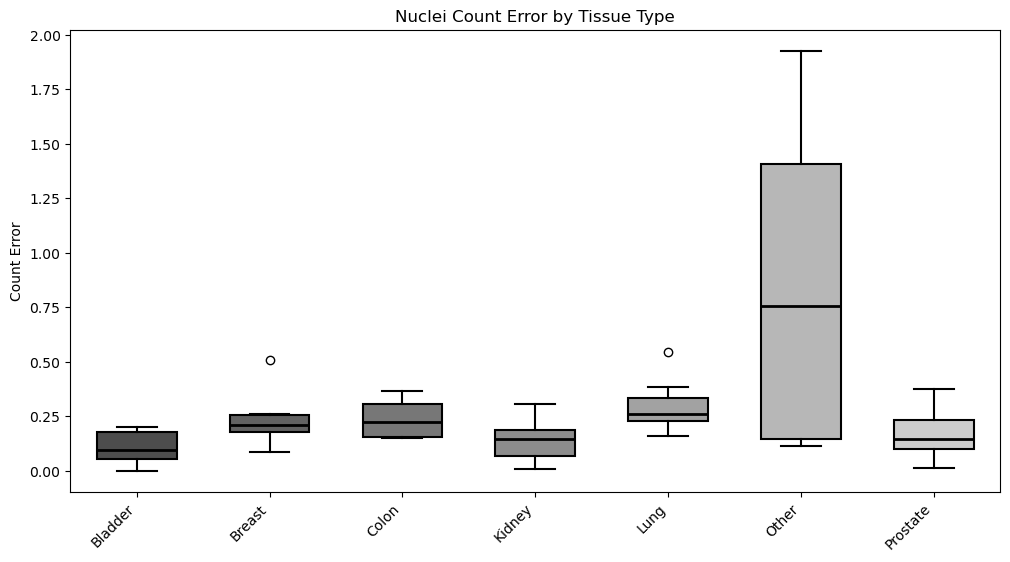

In [110]:
df = df_test_results.copy()

# Remove missing values
df = df.dropna(subset=["tissue_group", "count_error"])

# Sort tissue groups
tissues = sorted(df["tissue_group"].unique())

# Collect count error values per tissue
data = [df[df["tissue_group"] == t]["count_error"] for t in tissues]

plt.figure(figsize=(12, 6))

box = plt.boxplot(
    data,
    patch_artist=True,
    widths=0.6
)

# Shades of gray
gray_colors = np.linspace(0.3, 0.8, len(tissues))

for patch, color in zip(box["boxes"], gray_colors):
    patch.set_facecolor(str(color))
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

plt.xticks(range(1, len(tissues) + 1), tissues, rotation=45, ha="right")
plt.ylabel("Count Error")
plt.title("Nuclei Count Error by Tissue Type")
plt.grid(False)

plt.savefig("Count_Error_By_Tissue_Type.jpg", dpi=300, bbox_inches="tight")
plt.show()

## Make quadrants for each data type

In [9]:
import os
from tifffile import imread, imwrite

def split_into_quadrants(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for filename in os.listdir(input_dir):
        if not filename.endswith(".tif"):
            continue

        path = os.path.join(input_dir, filename)
        img = imread(path)

        h, w = img.shape[:2]
        h_mid = h // 2
        w_mid = w // 2

        base = os.path.splitext(filename)[0].replace("_mask", "")
        
        quadrants = [
            img[:h_mid, :w_mid],     # patch_0 (top-left)
            img[:h_mid, w_mid:],     # patch_1 (top-right)
            img[h_mid:, :w_mid],     # patch_2 (bottom-left)
            img[h_mid:, w_mid:]      # patch_3 (bottom-right)
        ]

        for i, q in enumerate(quadrants):
            out_name = f"{base}_patch_{i}_mask.tif"
            out_path = os.path.join(output_dir, out_name)

            imwrite(out_path, q)

        print("Saved patches for:", filename)

In [11]:
image_input_dir = "./Dataset/Test/Binary_Masks/"
image_output_dir = "./Dataset/Test/Mask_Patches/"

split_into_quadrants(image_input_dir, image_output_dir)

Saved patches for: TCGA-2Z-A9J9-01A-01-TS1_mask.tif
Saved patches for: TCGA-44-2665-01B-06-BS6_mask.tif
Saved patches for: TCGA-69-7764-01A-01-TS1_mask.tif
Saved patches for: TCGA-A6-6782-01A-01-BS1_mask.tif
Saved patches for: TCGA-AC-A2FO-01A-01-TS1_mask.tif
Saved patches for: TCGA-AO-A0J2-01A-01-BSA_mask.tif
Saved patches for: TCGA-CU-A0YN-01A-02-BSB_mask.tif
Saved patches for: TCGA-EJ-A46H-01A-03-TSC_mask.tif
Saved patches for: TCGA-FG-A4MU-01B-01-TS1_mask.tif
Saved patches for: TCGA-GL-6846-01A-01-BS1_mask.tif
Saved patches for: TCGA-HC-7209-01A-01-TS1_mask.tif
Saved patches for: TCGA-HT-8564-01Z-00-DX1_mask.tif
Saved patches for: TCGA-IZ-8196-01A-01-BS1_mask.tif
Saved patches for: TCGA-ZF-A9R5-01A-01-TS1_mask.tif
